# Gaussian Mixture Models — An Illustrated Tour

> A GMM models the data as a **weighted sum of $K$ Gaussians**. Unlike K-Means, each Gaussian has its own *shape* (covariance) and each point gets a **soft assignment** — a probability of belonging to each cluster.

---

**What we cover:**
- The model: $p(x) = \sum_k \pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k)$
- EM algorithm — alternate responsibilities (E-step) and parameter updates (M-step)
- Iteration snapshots — watch the ellipses settle
- Covariance types — spherical / diag / tied / full
- Soft assignments — colour by responsibility
- Choosing $K$ with BIC

## The picture — each cluster is a Gaussian (ellipse); soft probabilistic assignment

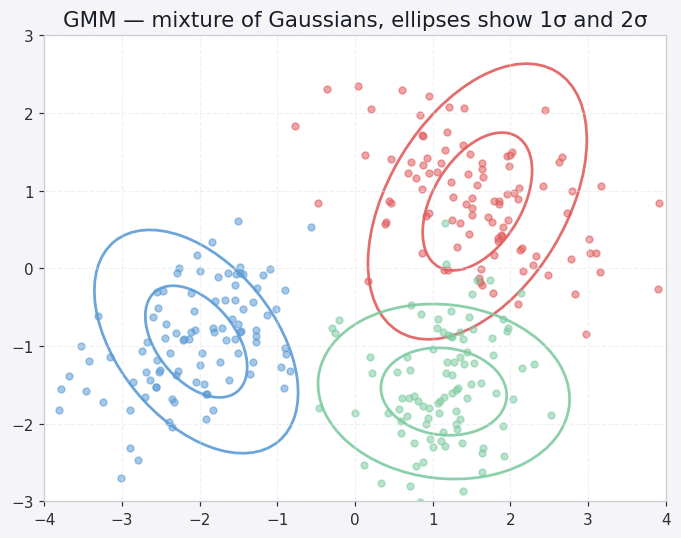

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
X1 = rng.multivariate_normal([-2,-1], [[0.5,0.2],[0.2,0.4]], 100)
X2 = rng.multivariate_normal([1.5, 1], [[0.8,-0.3],[-0.3,0.6]], 100)
X3 = rng.multivariate_normal([1.2,-1.5],[[0.3,0],[0,0.6]], 100)
fig, ax = plt.subplots(figsize=(7, 5))
for Xi, c in zip([X1,X2,X3], [P[0],P[1],P[3]]):
    ax.scatter(Xi[:,0], Xi[:,1], s=20, color=c, alpha=0.55)
    mu = Xi.mean(0); cov = np.cov(Xi.T)
    vals, vecs = np.linalg.eigh(cov); ang = np.degrees(np.arctan2(*vecs[:,1][::-1]))
    for k in [1, 2]:
        ax.add_patch(Ellipse(mu, 2*k*np.sqrt(vals[0]), 2*k*np.sqrt(vals[1]),
                             angle=ang, edgecolor=c, facecolor='none', lw=1.8, alpha=0.9))
ax.set_aspect('equal'); ax.set_xlim(-4,4); ax.set_ylim(-3,3)
ax.set_title('GMM — mixture of Gaussians, ellipses show 1σ and 2σ')
ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'
PALETTE = [C0, C1, CB, CM, CH, CP]

rng = np.random.default_rng(0)
X, _ = make_blobs(n_samples=200, centers=3, cluster_std=[0.8, 1.4, 0.5], random_state=7)
T = np.array([[1.0, 0.6], [0.0, 0.7]])
X = X @ T  # add some anisotropy
print('Data:', X.shape)

Data: (200, 2)


---
## The Model

$$p(x) \;=\; \sum_{k=1}^{K} \pi_k \,\mathcal{N}\bigl(x \,\mid\, \mu_k,\, \Sigma_k\bigr), \qquad \sum_k \pi_k = 1.$$

Three sets of parameters per cluster:
- **mixing weight** $\pi_k$ — how often this Gaussian is drawn,
- **mean** $\mu_k$ — centre of the ellipse,
- **covariance** $\Sigma_k$ — shape, size, orientation of the ellipse.

**EM algorithm** finds the maximum-likelihood parameters by alternating:
- **E-step**: responsibilities $\gamma_{ik} = \dfrac{\pi_k \,\mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_j \pi_j \,\mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$.
- **M-step**: $\pi_k = \bar\gamma_k$, $\mu_k = \sum_i \gamma_{ik} x_i / N_k$, $\Sigma_k = \sum_i \gamma_{ik}(x_i-\mu_k)(x_i-\mu_k)^T / N_k$.

Log-likelihood increases monotonically each iteration.

/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/home/sandeep/workspace/learn-ml/.venv/lib/python3.10/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different ini

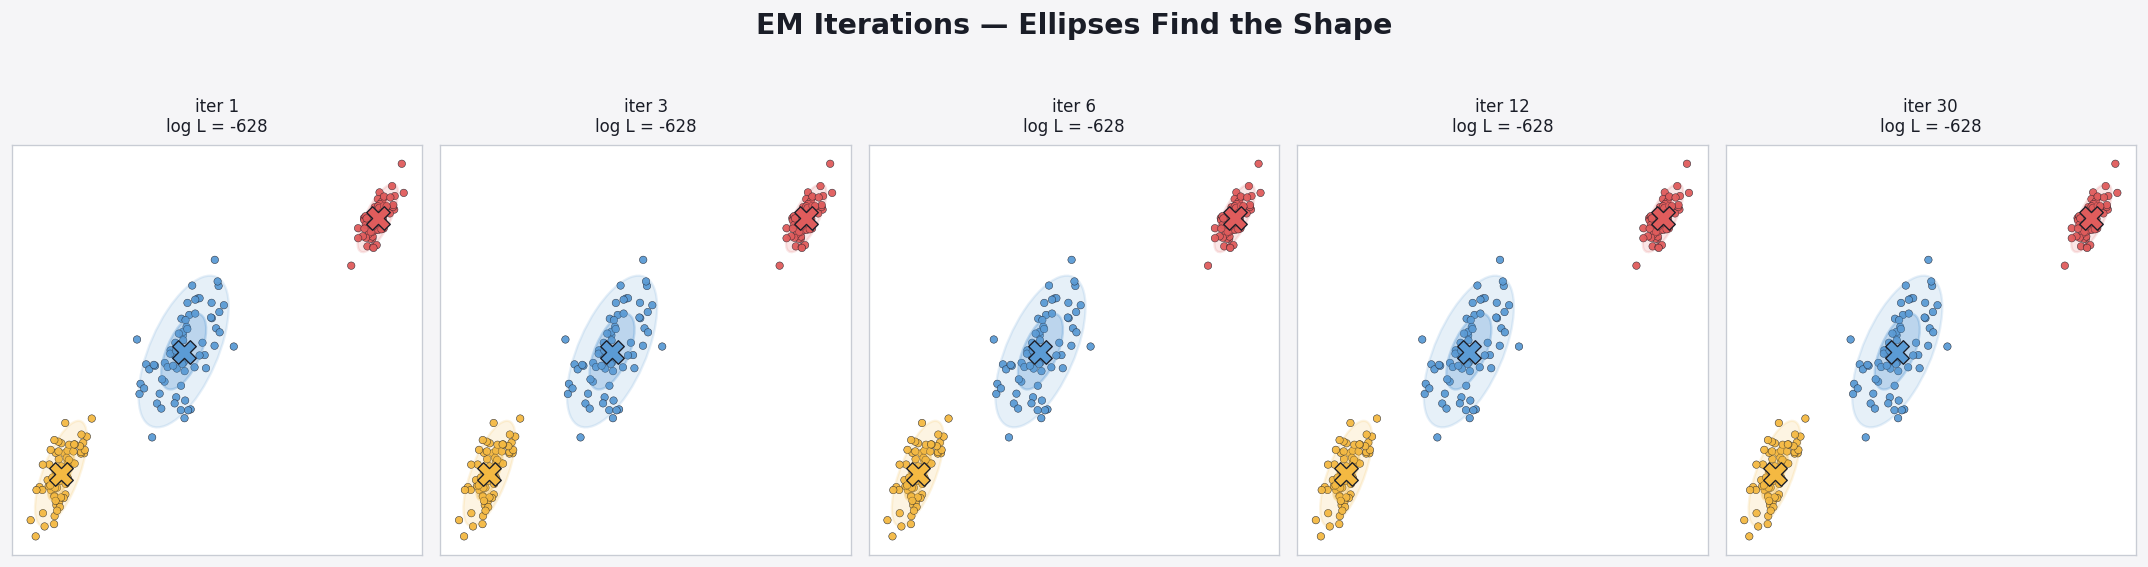

In [3]:
def draw_ellipse(ax, mean, cov, color, alpha=0.30):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]; vals = vals[order]; vecs = vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    for nstd in [1, 2]:
        w, h = 2 * nstd * np.sqrt(vals)
        e = Ellipse(xy=mean, width=w, height=h, angle=angle,
                    facecolor=color, edgecolor=color, lw=1.4, alpha=alpha/nstd)
        ax.add_patch(e)

snapshots = []
for n_it in [1, 3, 6, 12, 30]:
    g = GaussianMixture(n_components=3, max_iter=n_it, covariance_type='full',
                        init_params='kmeans', random_state=0, tol=0).fit(X)
    snapshots.append((n_it, g))

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5))
for ax, (it, g) in zip(axes, snapshots):
    resp = g.predict_proba(X)
    col = resp @ np.array([
        [int(c[1:3], 16), int(c[3:5], 16), int(c[5:7], 16)] for c in [C0, C1, CB]
    ]) / 255.0
    ax.scatter(X[:,0], X[:,1], c=col, s=20, edgecolors='#1a1d27', lw=0.3, alpha=0.95)
    for k, color in enumerate([C0, C1, CB]):
        draw_ellipse(ax, g.means_[k], g.covariances_[k], color)
        ax.scatter(*g.means_[k], s=200, c=color, marker='X', edgecolors='#1a1d27', lw=0.8, zorder=6)
    ax.set_title(f'iter {it}\nlog L = {g.score(X)*len(X):.0f}', fontsize=10, pad=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('EM Iterations — Ellipses Find the Shape', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Covariance Types — Constraints on the Ellipse

| `covariance_type` | $\Sigma_k$ shape | Looks like |
|---|---|---|
| `spherical` | $\sigma_k^2 I$ | Circle, per-cluster radius (≈ K-Means) |
| `diag` | diagonal | Axis-aligned ellipse |
| `tied` | shared full $\Sigma$ | Same ellipse shape for all clusters |
| `full` | per-cluster full $\Sigma$ | Arbitrary ellipse, per cluster |

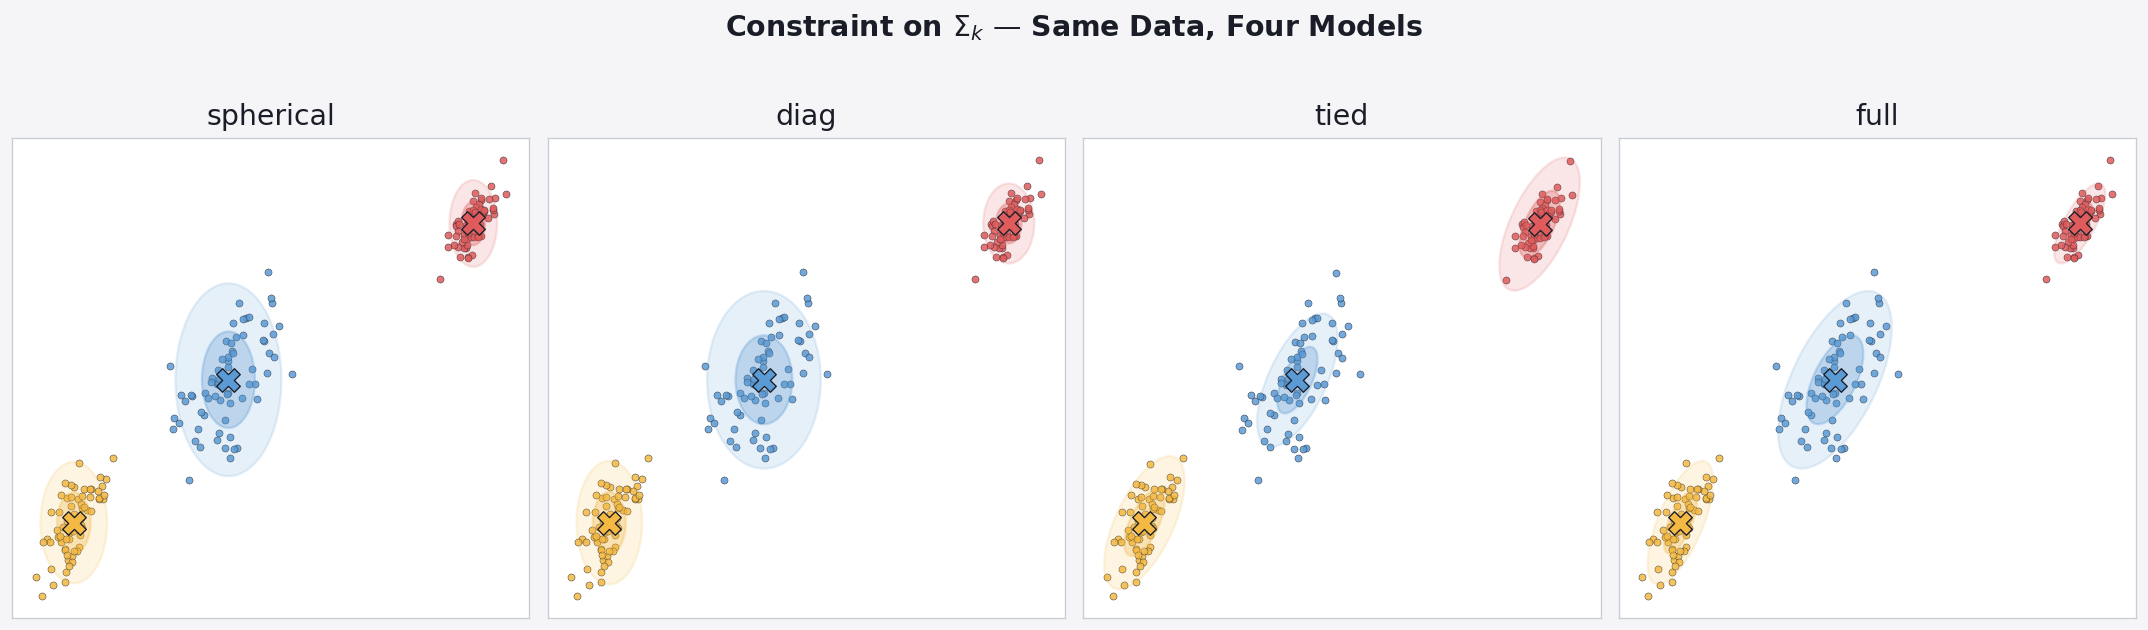

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, ctype in zip(axes, ['spherical', 'diag', 'tied', 'full']):
    g = GaussianMixture(n_components=3, covariance_type=ctype, random_state=0).fit(X)
    lbl = g.predict(X)
    for k in range(3):
        m = lbl == k
        ax.scatter(X[m,0], X[m,1], c=PALETTE[k], s=18, edgecolors='#1a1d27', lw=0.3, alpha=0.85)
        cov = g.covariances_
        if ctype == 'spherical': cov_k = np.eye(2) * cov[k]
        elif ctype == 'diag':    cov_k = np.diag(cov[k])
        elif ctype == 'tied':    cov_k = cov
        else:                    cov_k = cov[k]
        draw_ellipse(ax, g.means_[k], cov_k, PALETTE[k])
        ax.scatter(*g.means_[k], s=200, c=PALETTE[k], marker='X', edgecolors='#1a1d27', lw=0.8, zorder=6)
    ax.set_title(ctype, pad=8); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Constraint on $\\Sigma_k$ — Same Data, Four Models', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Soft vs Hard Assignments

K-Means hardens every point into one cluster. GMM keeps the **responsibility vector** $\gamma_i \in \Delta^{K-1}$ — a probability over clusters. Points near a cluster boundary inherit a mix of colours.

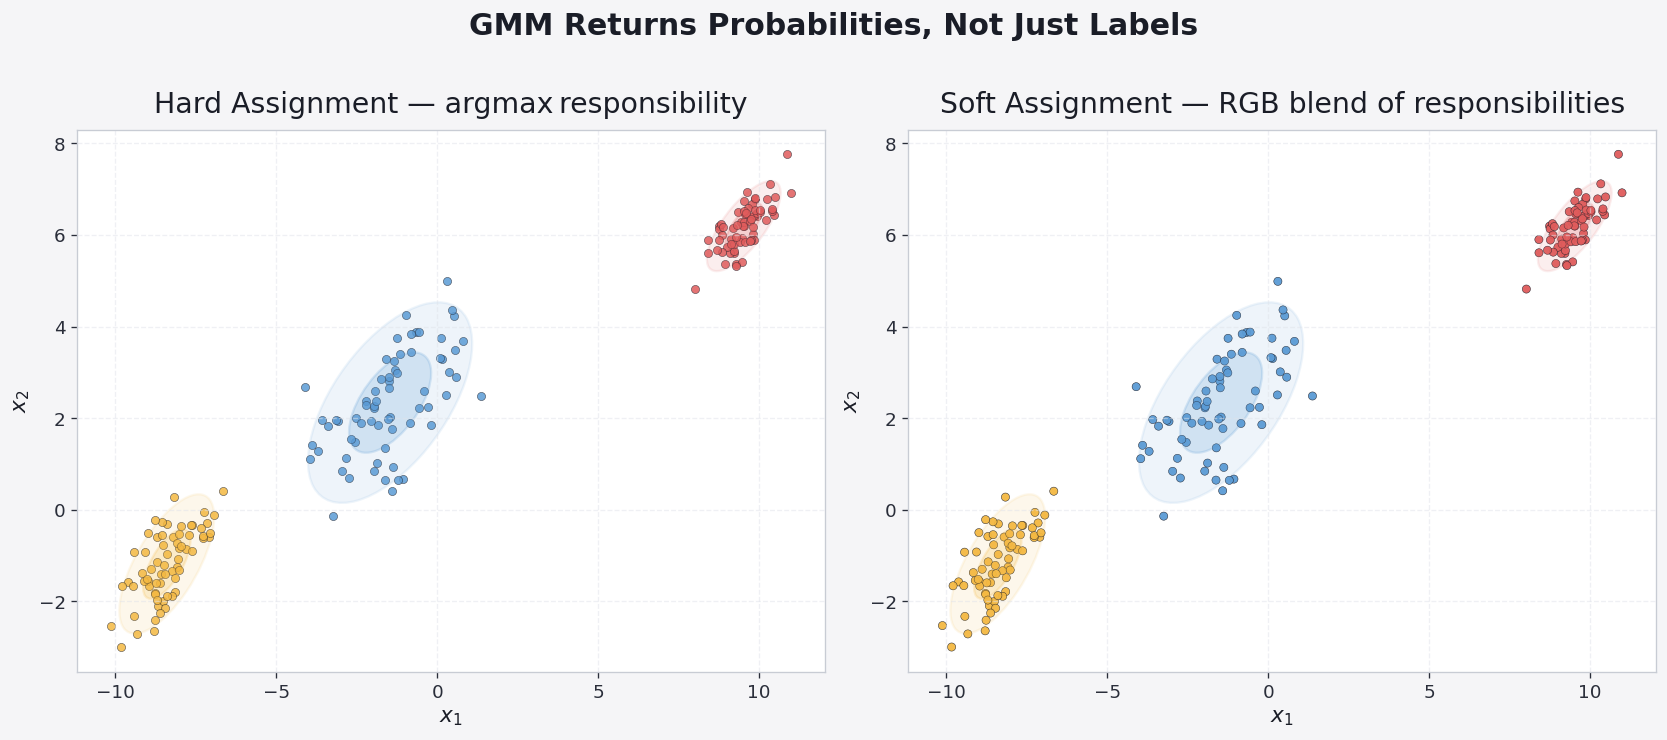

In [5]:
g = GaussianMixture(n_components=3, covariance_type='full', random_state=0).fit(X)
resp = g.predict_proba(X)
rgb = np.array([
    [int(c[1:3], 16), int(c[3:5], 16), int(c[5:7], 16)] for c in [C0, C1, CB]
]) / 255.0
soft_col = resp @ rgb

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
lbl = g.predict(X)
for k in range(3):
    m = lbl == k
    ax.scatter(X[m,0], X[m,1], c=PALETTE[k], s=24, edgecolors='#1a1d27', lw=0.3, alpha=0.85)
for k, color in enumerate([C0, C1, CB]):
    draw_ellipse(ax, g.means_[k], g.covariances_[k], color, alpha=0.20)
ax.set_title('Hard Assignment — argmax responsibility', pad=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

ax = axes[1]
ax.scatter(X[:,0], X[:,1], c=soft_col, s=24, edgecolors='#1a1d27', lw=0.3, alpha=0.95)
for k, color in enumerate([C0, C1, CB]):
    draw_ellipse(ax, g.means_[k], g.covariances_[k], color, alpha=0.20)
ax.set_title('Soft Assignment — RGB blend of responsibilities', pad=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)
fig.suptitle('GMM Returns Probabilities, Not Just Labels', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Choosing $K$ with BIC

The **Bayesian Information Criterion** $\text{BIC} = -2 \log L + p \log n$ trades off fit (log-likelihood) against complexity ($p$ parameters). Pick the $K$ that minimises BIC.

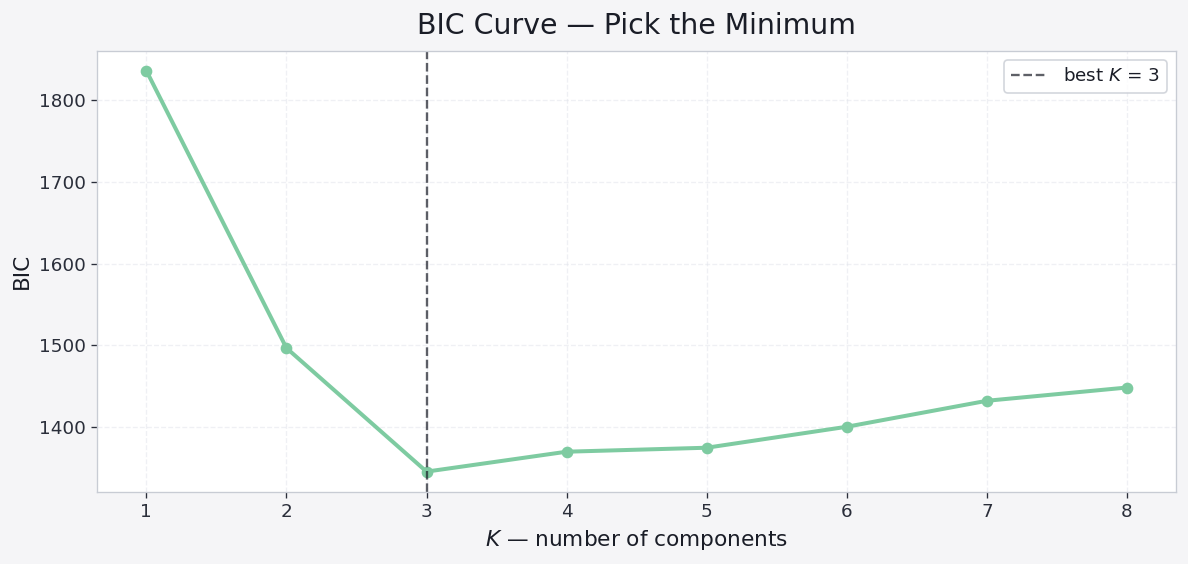

In [6]:
Ks = list(range(1, 9))
bic = [GaussianMixture(n_components=k, covariance_type='full', random_state=0).fit(X).bic(X) for k in Ks]
best_k = Ks[int(np.argmin(bic))]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(Ks, bic, color=CM, lw=2.4, marker='o', ms=6)
ax.axvline(best_k, color='#1a1d27', ls='--', lw=1.4, alpha=0.7, label=f'best $K$ = {best_k}')
ax.set_xlabel('$K$ — number of components')
ax.set_ylabel('BIC')
ax.set_title('BIC Curve — Pick the Minimum', pad=10)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use a GMM — and when not to

| Situation | GMM | K-Means | DBSCAN | KDE |
|---|---|---|---|---|
| Soft cluster membership | ✅ posteriors | ❌ hard | ❌ | partial |
| Need a generative model | ✅ sample from $p(x)$ | ❌ | ❌ | ✅ but heavy |
| Non-axis-aligned ellipses | ✅ full covariance | ❌ | ✅ | ✅ |
| Selecting $k$ automatically | partial (BIC) | ❌ | ✅ | ❌ |

> A GMM is **K-Means with shape and uncertainty** — and a real probability density model.


---
## 🎯 Try this

1. **Covariance type.** Refit with `spherical`, `diag`, `tied`, `full`. Plot the ellipses — the right choice depends on how your clusters are oriented.
2. **BIC for $k$.** Sweep `n_components` from 1 to 10 and plot BIC. The minimum is a principled choice for $k$ without a held-out set.
3. **EM by hand.** Implement one E-step (compute responsibilities) and one M-step (update $\pi, \mu, \Sigma$) and verify it agrees with sklearn after a few iterations.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Mixture model | Sum of weighted Gaussians | Generative model of the data |
| Responsibility | $\gamma_{ik}$ — probability of cluster $k$ for point $i$ | Soft assignment |
| EM | E-step responsibilities, M-step parameters | Log-likelihood monotonically up |
| Covariance type | spherical / diag / tied / full | Trades flexibility vs # params |
| BIC | $-2 \log L + p \log n$ | Picks $K$ |
| Strength vs K-Means | Elliptical clusters, soft labels, density | More expressive when shapes matter |
| Weakness | Local optima, must pick $K$, sensitive to init | Use `n_init>1` and BIC to mitigate |

**Bottom line:** A GMM is K-Means with **shape and uncertainty**. Each cluster has its own ellipse, every point gets a probability vector, and you can score the data under the model $p(x)$.